In [1]:
import pandas as pd
import numpy as np
import os

dataset_A_320k = pd.read_csv('../Cleaned Dataset/Dataset_A.csv')
dataset_B_70k  = pd.read_csv('../Cleaned Dataset/Dataset_B.csv')
dataset_C_1500 = pd.read_csv('../Cleaned Dataset/Dataset_C.csv') # Unseen test dataset


In [6]:
#Mix dataset_B randomly
from random import shuffle
dataset_B_shuffled = dataset_B_70k.sample(frac=1, random_state=42).reset_index(drop=True)

dataset_B_shuffled.head()


,id,Age,Gender,Systolic Blood Pressure,Diastolic Blood Pressure,Cholesterol Level,Glucose Level,Smoking Status,Alcohol Intake,Physical Activity,Cardiovascular Disease,BMI
0,50298,63,1,120,70,2,1,0,0,1,1,29.6
1,31179,45,1,170,110,2,1,0,0,1,1,35.8
2,41076,63,2,120,80,2,2,0,0,1,1,29.1
3,93648,59,1,120,80,1,1,0,0,1,1,23.9
4,86366,49,1,120,80,1,1,0,0,1,0,26.3


In [7]:
#Split dataset_B_shuffled into 80% (training) and 20% (testing)
split_80 = int(len(dataset_B_shuffled) * 0.8)

datasetB_80_percent = dataset_B_shuffled.iloc[:split_80].reset_index(drop=True)
datasetB_20_percent_test = dataset_B_shuffled.iloc[split_80:].reset_index(drop=True)

print(f"Dataset B 80%: {len(datasetB_80_percent)} samples")
print(f"Dataset B 20% (Test): {len(datasetB_20_percent_test)} samples")

Dataset B 80%: 54608 samples
Dataset B 20% (Test): 13652 samples


In [ ]:
#Sort columns alphabetically
dataset_A_320k = dataset_A_320k[sorted(dataset_A_320k.columns)]
datasetB_80_percent = datasetB_80_percent[sorted(datasetB_80_percent.columns)]
datasetB_20_percent_test = datasetB_20_percent_test[sorted(datasetB_20_percent_test.columns)]
dataset_C_1500 = dataset_C_1500[sorted(dataset_C_1500.columns)]

# Save the 20% of Dataset B for testing purposes
datasetB_20_percent_test.to_csv('datasetB_20_percent_test.csv', index=False)
print(f"Saved 20% of Dataset B for testing: {len(datasetB_20_percent_test)} samples")

# Save the 80% of Dataset B (full version with all columns)
datasetB_80_percent.to_csv('datasetB_80_percent.csv', index=False)
print(f"Saved 80% of Dataset B: {len(datasetB_80_percent)} samples")

Saved 20% of Dataset B for testing: 13652 samples


## Create LifeStyle Dataset

In [9]:
# Model A Dataset: 80% of B + same count from A
# Sample from A the same count as 80% of B
count_80_B = len(datasetB_80_percent)
dataset_A_sampled = dataset_A_320k.sample(n=count_80_B, random_state=42).reset_index(drop=True)

print(f"Sampled {len(dataset_A_sampled)} samples from Dataset A (matching 80% of B)")

# Drop columns not needed for lifestyle model from 80% of B
columns_to_drop = ['Cholesterol Level', 'Diastolic Blood Pressure', 'Systolic Blood Pressure', 'Glucose Level', 'id']
datasetB_for_lifestyle = datasetB_80_percent.drop(columns=columns_to_drop)

# Merge dataset_A_sampled with datasetB_for_lifestyle
lifestyle_dataset = pd.concat([dataset_A_sampled, datasetB_for_lifestyle],
                              axis=0,
                              ignore_index=True,
                              sort=False)

# Shuffle the lifestyle dataset
lifestyle_dataset = lifestyle_dataset.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Lifestyle Dataset (Model A): {len(lifestyle_dataset)} samples")
print(f"  - From Dataset A: {len(dataset_A_sampled)}")
print(f"  - From Dataset B (80%): {len(datasetB_for_lifestyle)}")

# Output the lifestyle dataset to a CSV file
lifestyle_dataset.to_csv('lifestyle_dataset_issue_3.csv', index=False)

Sampled 54608 samples from Dataset A (matching 80% of B)
Lifestyle Dataset (Model A): 109216 samples
  - From Dataset A: 54608
  - From Dataset B (80%): 54608


## Create HealthFactors Dataset

In [10]:
# Model B Dataset: 80% of B + full Dataset C
B_columns_to_drop = ['Smoking Status', 'Physical Activity', 'Alcohol Intake', 'id']
C_columns_to_drop = ['Smoking Status', 'Physical Activity', 'Alcohol Intake']

# Drop columns not needed for health factors model
datasetB_for_health = datasetB_80_percent.drop(columns=B_columns_to_drop)
dataset_C_for_health = dataset_C_1500.drop(columns=C_columns_to_drop)

# Merge 80% of B with full Dataset C
health_factors_dataset = pd.concat([datasetB_for_health, dataset_C_for_health], 
                                    axis=0, 
                                    ignore_index=True, 
                                    sort=False)

# Shuffle the health factors dataset
health_factors_dataset = health_factors_dataset.sample(frac=1, random_state=50).reset_index(drop=True)

print(f"Health Factors Dataset (Model B): {len(health_factors_dataset)} samples")
print(f"  - From Dataset B (80%): {len(datasetB_for_health)}")
print(f"  - From Dataset C: {len(dataset_C_for_health)}")

# Output the health factors dataset to a CSV file
health_factors_dataset.to_csv('healthFactors_dataset.csv', index=False)

Health Factors Dataset (Model B): 56137 samples
  - From Dataset B (80%): 54608
  - From Dataset C: 1529


In [11]:
# Health Factor dataset with minority indicator (optional)
dataset_C_with_indicator = dataset_C_1500.drop(columns=C_columns_to_drop).copy()
datasetB_with_indicator = datasetB_80_percent.drop(columns=B_columns_to_drop).copy()

dataset_C_with_indicator['Is Minority'] = 1
datasetB_with_indicator['Is Minority'] = 0 

# Merge 80% of B with full Dataset C (with indicator)
health_factors_with_indicator = pd.concat([datasetB_with_indicator, dataset_C_with_indicator], 
                                           axis=0, 
                                           ignore_index=True, 
                                           sort=False)

# Shuffle the health factors dataset
health_factors_with_indicator = health_factors_with_indicator.sample(frac=1, random_state=50).reset_index(drop=True)

# Output the health factors dataset to a CSV file
health_factors_with_indicator.to_csv('healthFactors_dataset_with_indicator.csv', index=False)
print(f"Health Factors Dataset with Indicator saved: {len(health_factors_with_indicator)} samples")

Health Factors Dataset with Indicator saved: 56137 samples


## Data distributions

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_all_distributions(df: pd.DataFrame, color='blue'):
    """
    Plot distributions for all columns in the DataFrame.

    Numeric columns: histogram with KDE.
    Categorical columns: count plot.

    Args:
        df (pd.DataFrame): Input data.
        color (str): Color for the plots (default: 'blue').
    """
    num_cols = df.select_dtypes(include=['number']).columns
    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns

    num_plots = len(num_cols) + len(cat_cols)
    ncols = 3
    nrows = (num_plots + ncols - 1) // ncols

    plt.figure(figsize=(5 * ncols, 4 * nrows))

    # Plot numerical columns
    for idx, col in enumerate(num_cols, 1):
        plt.subplot(nrows, ncols, idx)
        sns.histplot(df[col].dropna(), color=color, kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)

    # Plot categorical columns
    for idx_cat, col in enumerate(cat_cols, len(num_cols) + 1):
        plt.subplot(nrows, ncols, idx_cat)
        sns.countplot(x=df[col], color=color, order=df[col].value_counts().index)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()



# Comparing dataset_B_Model_A and lifestyle_dataset

In [16]:
dataset_B_70k['Age'].unique()

array([50, 55, 51, 48, 47, 60, 61, 54, 40, 39, 45, 58, 59, 63, 64, 53, 49,
       57, 56, 46, 43, 62, 52, 42, 44, 41, 29, 30])

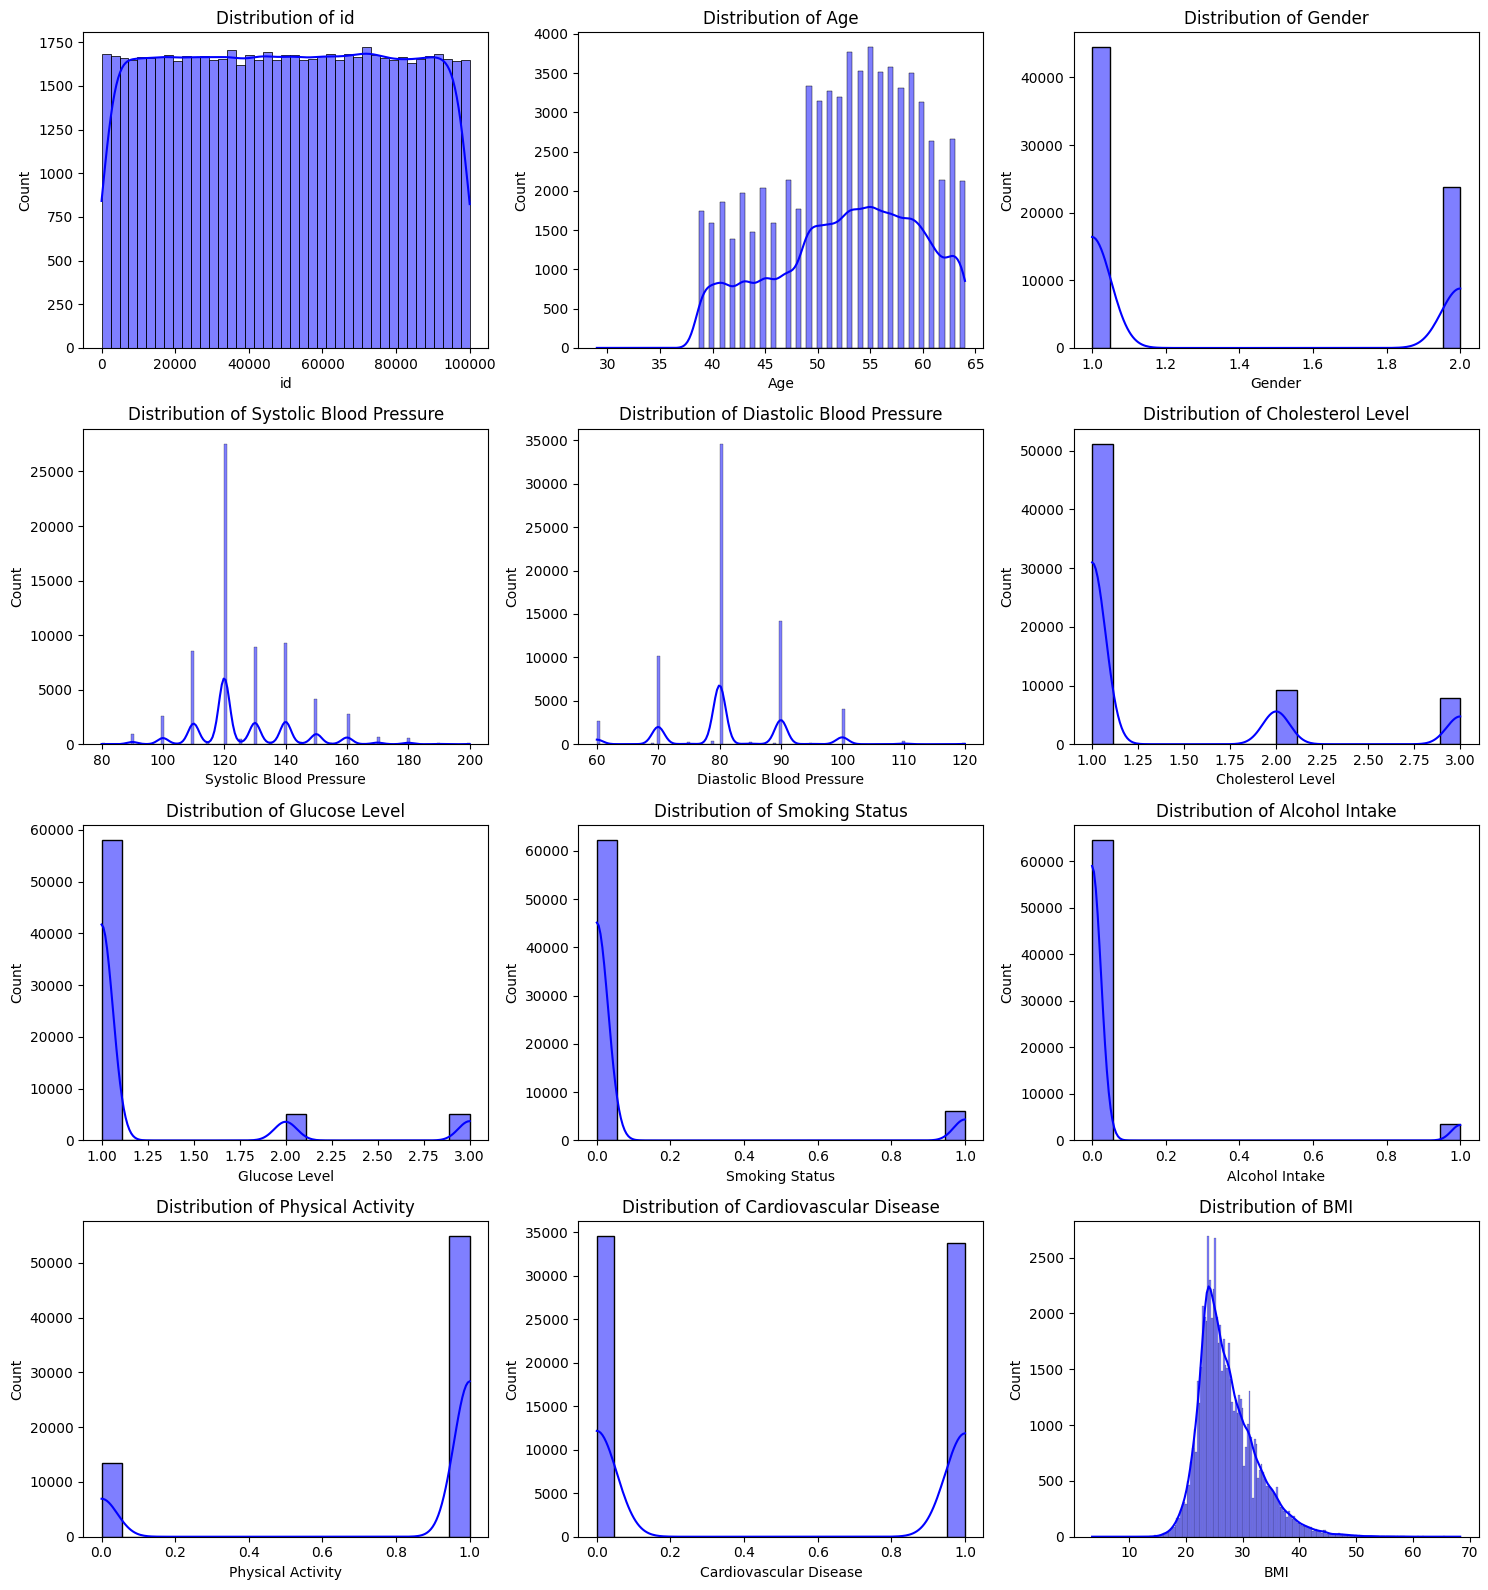

In [17]:
plot_all_distributions(dataset_B_70k)

In [ ]:
plot_all_distributions(dataset_B_Model_A, color='green')

NameError: name 'dataset_B_Model_A' is not defined

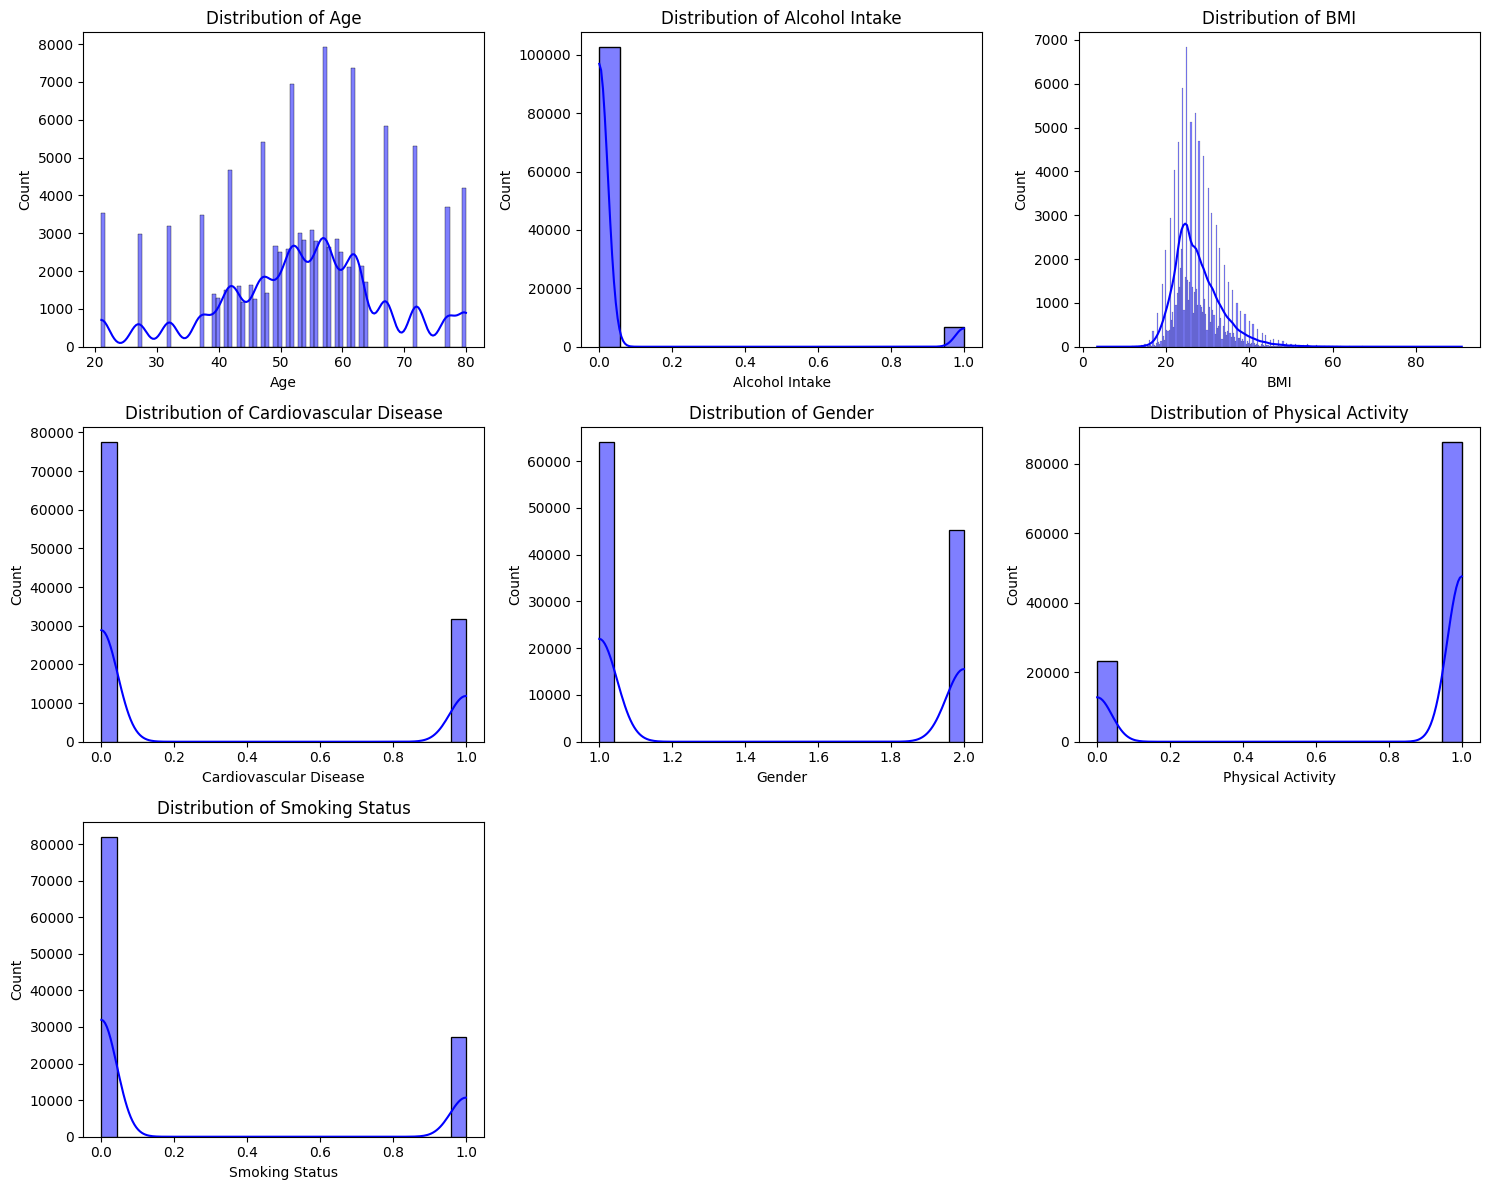

In [19]:
plot_all_distributions(lifestyle_dataset, color='blue')

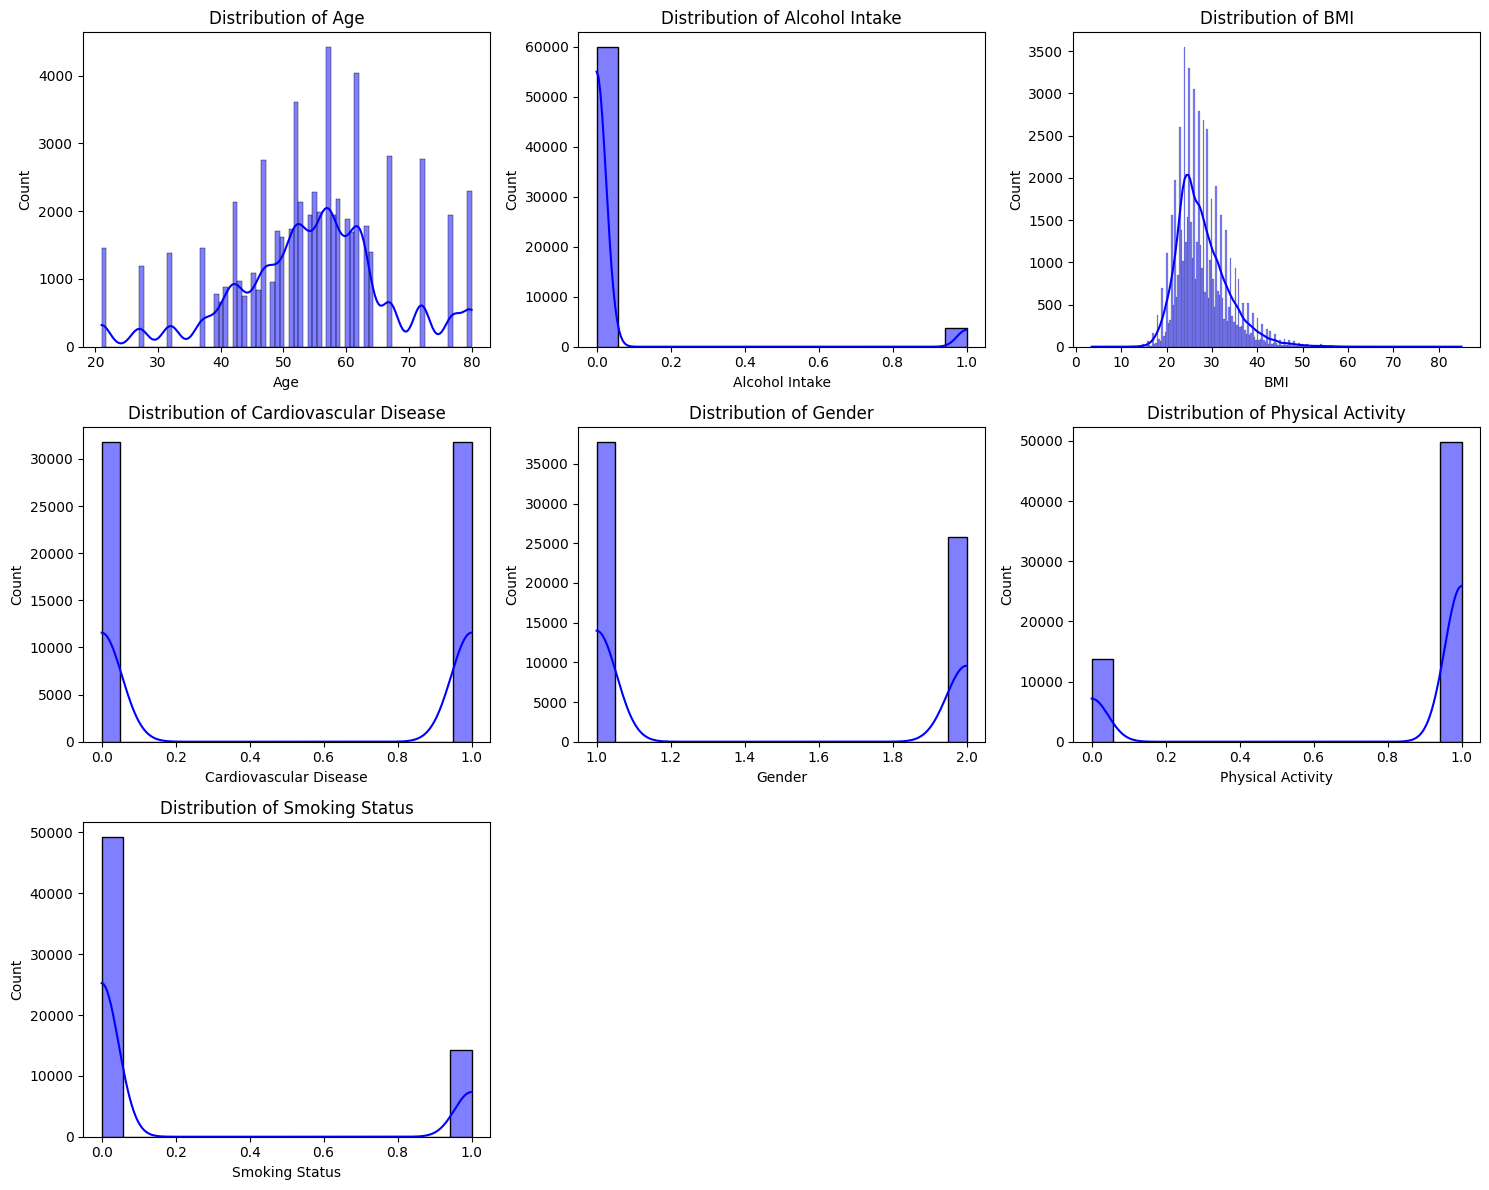

In [27]:
plot_all_distributions(lifestyle_balanced_under, color='blue')


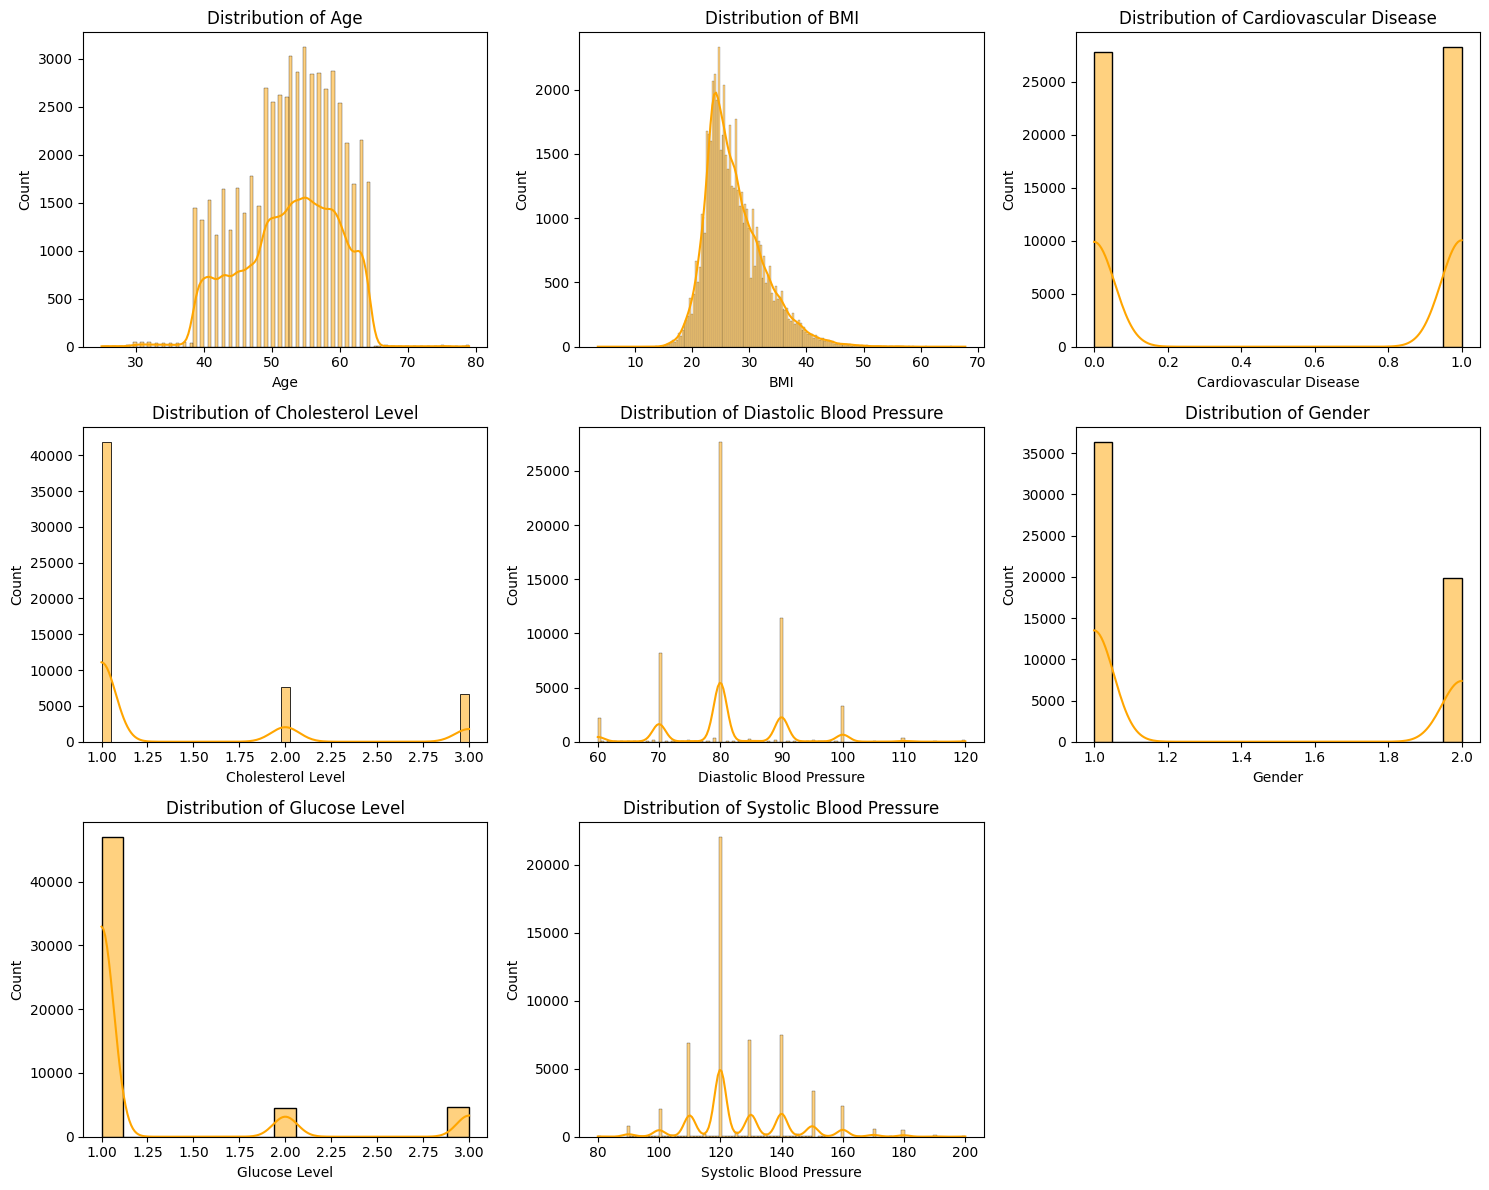

In [20]:
plot_all_distributions(health_factors_dataset, color='orange')

In [ ]:
# Meta Model Dataset: only 80% of Dataset B
meta_model_dataset = datasetB_80_percent.copy()

# Shuffle the meta model dataset
meta_model_dataset = meta_model_dataset.sample(frac=1, random_state=42).reset_index(drop=True)

# Save the meta model dataset
meta_model_dataset.to_csv('Training_For_Meta_Model.csv', index=False)
print(f"Meta Model Dataset saved: {len(meta_model_dataset)} samples (80% of Dataset B)")

## Balance Target Variable (CVD)

In [21]:
# Check current class distribution
print("LIFESTYLE DATASET:")
print(lifestyle_dataset['Cardiovascular Disease'].value_counts())
print(f"Imbalance ratio: {lifestyle_dataset['Cardiovascular Disease'].value_counts().iloc[0] / lifestyle_dataset['Cardiovascular Disease'].value_counts().iloc[1]:.2f}:1")

print("\nHEALTH FACTORS DATASET:")
print(health_factors_dataset['Cardiovascular Disease'].value_counts())
print(f"Imbalance ratio: {health_factors_dataset['Cardiovascular Disease'].value_counts().iloc[0] / health_factors_dataset['Cardiovascular Disease'].value_counts().iloc[1]:.2f}:1")

LIFESTYLE DATASET:
Cardiovascular Disease
0    77451
1    31765
Name: count, dtype: int64
Imbalance ratio: 2.44:1

HEALTH FACTORS DATASET:
Cardiovascular Disease
1    28269
0    27868
Name: count, dtype: int64
Imbalance ratio: 1.01:1


### Option 1: Undersample Majority Class (Reduce no-disease samples)

In [24]:
def undersample_majority(df, target_col='Cardiovascular Disease', random_state=42):
    """
    Undersample the majority class to match the minority class count.
    Automatically detects which class is minority/majority.
    """
    # Separate by class
    df_class_0 = df[df[target_col] == 0]
    df_class_1 = df[df[target_col] == 1]
    
    # Determine which is minority and which is majority
    if len(df_class_0) > len(df_class_1):
        df_majority = df_class_0
        df_minority = df_class_1
        print(f"Class 0 is majority ({len(df_class_0)}), Class 1 is minority ({len(df_class_1)})")
    else:
        df_majority = df_class_1
        df_minority = df_class_0
        print(f"Class 1 is majority ({len(df_class_1)}), Class 0 is minority ({len(df_class_0)})")
    
    # Undersample majority
    df_majority_undersampled = df_majority.sample(n=len(df_minority), random_state=random_state)
    
    # Combine and shuffle
    df_balanced = pd.concat([df_minority, df_majority_undersampled], axis=0)
    df_balanced = df_balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    return df_balanced

# Apply to lifestyle dataset
lifestyle_balanced_under = undersample_majority(lifestyle_dataset)
print(f"Original Lifestyle Dataset: {len(lifestyle_dataset)} samples")
print(f"Balanced Lifestyle Dataset (Undersampled): {len(lifestyle_balanced_under)} samples")
print(lifestyle_balanced_under['Cardiovascular Disease'].value_counts())

# Apply to health factors dataset
health_balanced_under = undersample_majority(health_factors_dataset)
print(f"\nOriginal Health Factors Dataset: {len(health_factors_dataset)} samples")
print(f"Balanced Health Factors Dataset (Undersampled): {len(health_balanced_under)} samples")
print(health_balanced_under['Cardiovascular Disease'].value_counts())

Class 0 is majority (77451), Class 1 is minority (31765)
Original Lifestyle Dataset: 109216 samples
Balanced Lifestyle Dataset (Undersampled): 63530 samples
Cardiovascular Disease
1    31765
0    31765
Name: count, dtype: int64
Class 1 is majority (28269), Class 0 is minority (27868)

Original Health Factors Dataset: 56137 samples
Balanced Health Factors Dataset (Undersampled): 55736 samples
Cardiovascular Disease
1    27868
0    27868
Name: count, dtype: int64


### Save Balanced Datasets (Choose one approach)

In [25]:
# Choose which balanced dataset to save:
# Option 1: Undersample (smaller dataset, no duplicates)
# Option 2: Oversample (larger dataset, has duplicates)
# Option 3: Hybrid (medium dataset, some duplicates)

# Example: Save undersampled version
lifestyle_balanced_under.to_csv('lifestyle_dataset_balanced_under.csv', index=False)
health_balanced_under.to_csv('healthFactors_dataset_balanced_under.csv', index=False)

# Or save oversampled version
# lifestyle_balanced_over.to_csv('lifestyle_dataset_balanced_over.csv', index=False)
# health_balanced_over.to_csv('healthFactors_dataset_balanced_over.csv', index=False)

# Or save hybrid version
# lifestyle_balanced_hybrid.to_csv('lifestyle_dataset_balanced_hybrid.csv', index=False)
# health_balanced_hybrid.to_csv('healthFactors_dataset_balanced_hybrid.csv', index=False)

print("Balanced datasets saved!")

Balanced datasets saved!
